In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(r"C:\Users\user\my_snippet\DataSets\e-commerce.csv",encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [10]:
df.isnull().sum()
df = df.dropna(subset=['CustomerID'])
df = df.drop_duplicates()

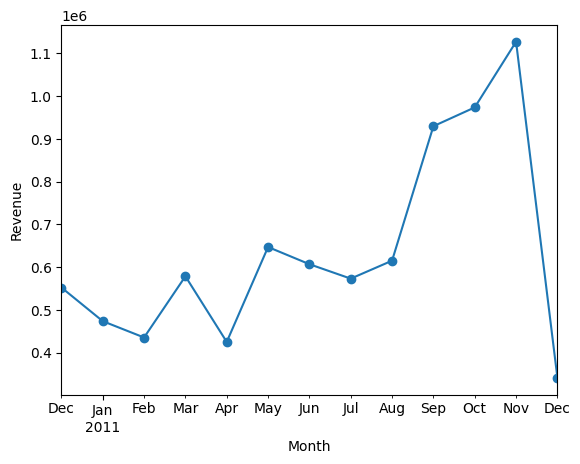

<Figure size 640x480 with 0 Axes>

In [11]:
# feature engineering

df['DateTime'] = pd.to_datetime(df['InvoiceDate'],format="%m/%d/%Y %H:%M")
df['month'] = df['DateTime'].dt.to_period('M')
df['revenue'] = df['Quantity'] * df['UnitPrice']
df['hour'] = df['DateTime'].dt.hour

# monthly revenue
g = df.groupby('month')['revenue'].sum()

#trend
g.plot(x=g.index,y=g.values,marker='o')

#g = df.groupby('month')['CustomerID'].nunique()
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks()
plt.show()
plt.tight_layout()

In [14]:
#which category earns most
df.groupby('StockCode')['revenue'].sum().sort_values(ascending=False).head(5)

StockCode
22423     132567.70
85123A     93923.15
85099B     83056.52
47566      67628.43
POST       66710.24
Name: revenue, dtype: float64

In [ ]:
#top 5 revenue generating country
df.groupby('Country')['revenue'].sum().sort_values(ascending=False).head(5)

Country
United Kingdom    6747156.154
Netherlands        284661.540
EIRE               250001.780
Germany            221509.470
France             196626.050
Name: revenue, dtype: float64

In [ ]:
#revenue per customer

df.groupby('CustomerID')['revenue'].mean()

#average basket size

df.groupby('CustomerID')['Quantity'].mean()

CustomerID
12346.0     0.000000
12347.0    13.505495
12348.0    75.516129
12349.0     8.643836
12350.0    11.588235
             ...    
18280.0     4.500000
18281.0     7.714286
18282.0     7.538462
18283.0     1.882108
18287.0    22.657143
Name: Quantity, Length: 4372, dtype: float64

In [19]:
#total number of transaction and unique customer number
len(df['InvoiceNo']),df['InvoiceNo'].nunique()

(401604, 22190)

In [20]:
#monthly revenue trend
df.groupby('month')['revenue'].sum().sort_values(ascending=False).head(5)

month
2011-11    1126815.070
2011-10     973306.380
2011-09     929356.232
2011-05     647011.670
2011-08     615078.090
Freq: M, Name: revenue, dtype: float64

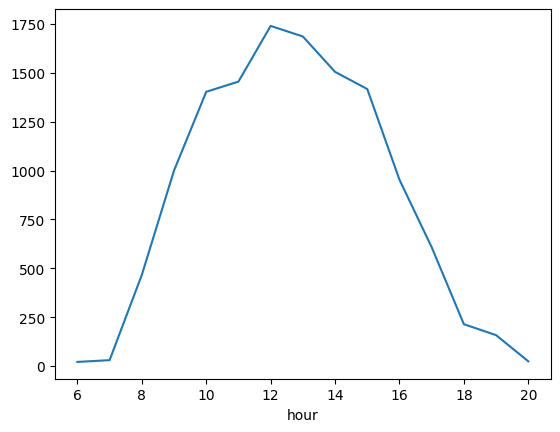

In [23]:
# hourly revenue
g = df.groupby('hour')['revenue'].sum()

busies_hour = df.groupby('hour')['CustomerID'].nunique().plot()

In [25]:
#most revenue earning category
df.groupby('Description')['revenue'].sum().sort_values(ascending=False).head(10)

Description
REGENCY CAKESTAND 3 TIER              132567.70
WHITE HANGING HEART T-LIGHT HOLDER     93767.80
JUMBO BAG RED RETROSPOT                83056.52
PARTY BUNTING                          67628.43
POSTAGE                                66710.24
ASSORTED COLOUR BIRD ORNAMENT          56331.91
RABBIT NIGHT LIGHT                     51042.84
CHILLI LIGHTS                          45915.41
PAPER CHAIN KIT 50'S CHRISTMAS         41423.78
PICNIC BASKET WICKER 60 PIECES         39619.50
Name: revenue, dtype: float64

<Axes: xlabel='month'>

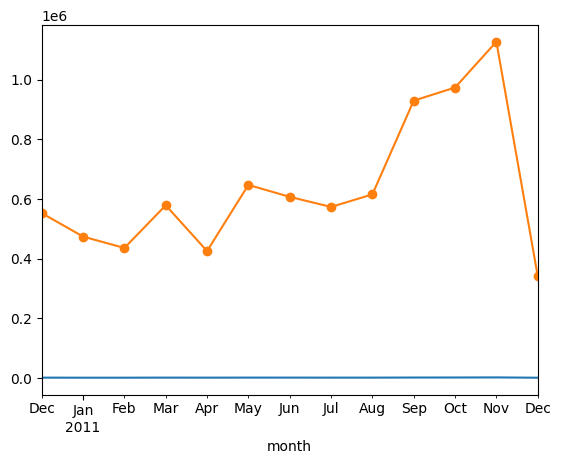

In [39]:
#numbr of transaction per month
df.groupby('month')['CustomerID'].nunique().plot()#accurate method of sales trend,use day hour etc
df.groupby('month')['revenue'].sum().plot(marker='o')#consider every row as new transaction,includes duplicate row as new element,not accurate

In [126]:
#average basket size 
df.groupby('CustomerID')['Quantity'].sum()
#country-wise performance:total customer and total revenue
df.groupby('Country').agg({'CustomerID':'nunique',
                           'revenue':'sum'}).idxmax()

CustomerID    United Kingdom
revenue       United Kingdom
dtype: str

In [127]:
df.groupby('Country')['Description'].value_counts().groupby(level=0).head(3)

Country         Description                        
Australia       SET OF 3 CAKE TINS PANTRY DESIGN         10
                LUNCH BAG RED RETROSPOT                   9
                RED TOADSTOOL LED NIGHT LIGHT             9
Austria         POSTAGE                                  14
                ROUND SNACK BOXES SET OF4 WOODLAND        4
                                                       ... 
United Kingdom  JUMBO BAG RED RETROSPOT                2001
                REGENCY CAKESTAND 3 TIER               1859
Unspecified     3 STRIPEY MICE FELTCRAFT                  4
                MINI JIGSAW CIRCUS PARADE                 3
                SET OF 6 3D KIT CARDS FOR KIDS            3
Name: count, Length: 114, dtype: int64